# Playground Aula 05

Libraries

In [122]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 12})

## Espaços de cor

Um espaço de cor define a interpretação dos três valores numéricos de cada pixel. A escolha do espaço adequado condiciona a dificuldade da tarefa. Este notebook compara o RGB e o HSV na segmentação de um objeto pela cor.

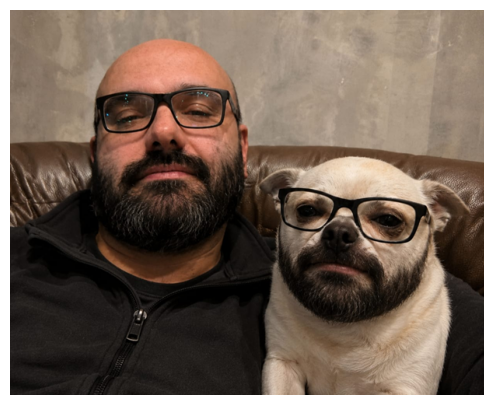

In [117]:
img = cv2.imread('../imgs/perfil.png')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### Canais RGB

`cv2.split` separa os canais. A ordem no OpenCV é B, G, R.

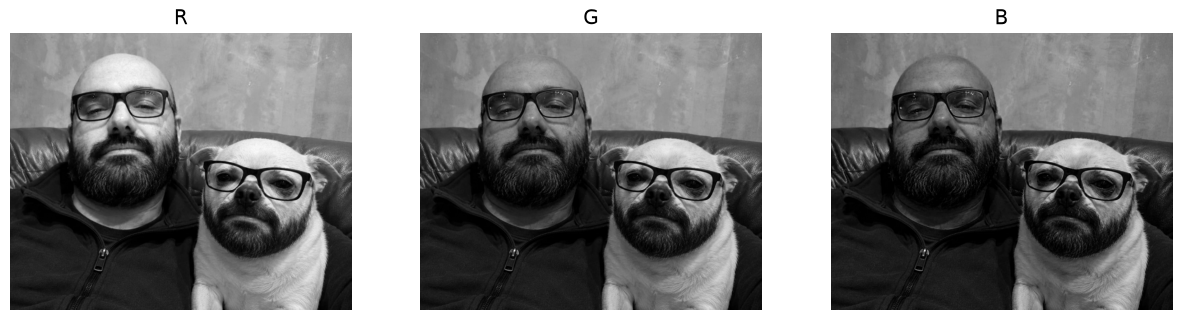

In [119]:
b, g, r = cv2.split(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, canal, nome in zip(axes, [r, g, b], ['R', 'G', 'B']):
    ax.imshow(canal, cmap='gray')
    ax.set_title(nome)
    ax.axis('off')

plt.show()

Uma regra de limiar direta sobre os canais RGB é sensível à iluminação: sombra e reflexo alteram os três canais simultaneamente, e a máscara resultante apresenta descontinuidades.

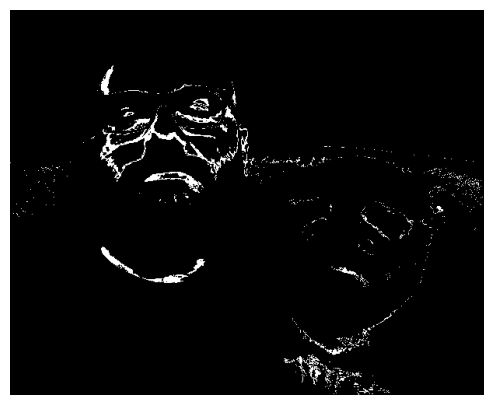

In [121]:
mask_rgb = ((r > 120) & (g < 100) & (b < 100)).astype(np.uint8) * 255

plt.imshow(mask_rgb, cmap = 'gray')
plt.axis('off')
plt.show()

### Distribuição dos pixels em RGB e HSV

Cada pixel é um ponto em um espaço tridimensional. A visualização abaixo apresenta os mesmos pixels nos dois sistemas de coordenadas.

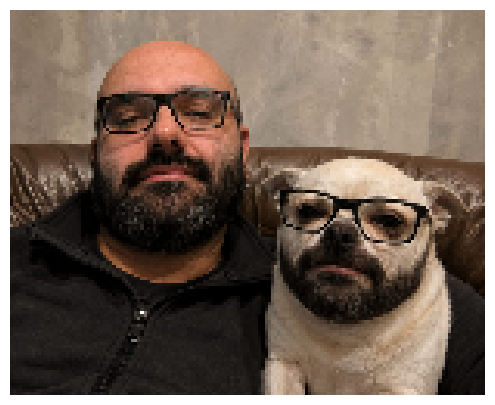

In [134]:
figuras = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
amostra = figuras[::4, ::4]
r, g, b = cv2.split(amostra)

plt.imshow(amostra, cmap = 'gray')
plt.axis('off')
plt.show()


pixel_colors = amostra.reshape((-1, 3))
norm = colors.Normalize(vmin=-1.0, vmax=1.0)
norm.autoscale(pixel_colors)
pixel_colors = norm(pixel_colors).tolist()



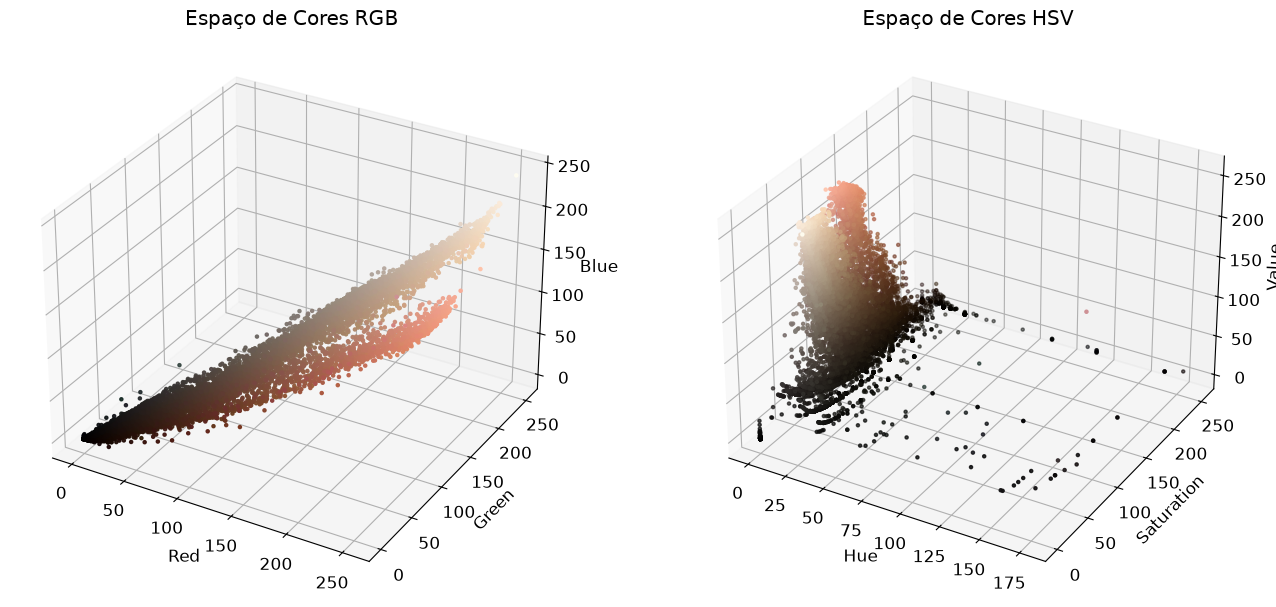

In [138]:
fig = plt.figure(figsize=(16, 8))

axis_rgb = fig.add_subplot(1, 2, 1, projection="3d")
axis_rgb.scatter(r.flatten(), g.flatten(), b.flatten(),
                 facecolors=pixel_colors, marker=".")
axis_rgb.set_xlabel("Red")
axis_rgb.set_ylabel("Green")
axis_rgb.set_zlabel("Blue")
axis_rgb.set_title("Espaço de Cores RGB")

hsv_figuras = cv2.cvtColor(amostra, cv2.COLOR_RGB2HSV)
hh, ss, vv = cv2.split(hsv_figuras)

axis_hsv = fig.add_subplot(1, 2, 2, projection="3d")
axis_hsv.scatter(hh.flatten(), ss.flatten(), vv.flatten(),
                 facecolors=pixel_colors, marker=".")
axis_hsv.set_xlabel("Hue")
axis_hsv.set_ylabel("Saturation")
axis_hsv.set_zlabel("Value")
axis_hsv.set_title("Espaço de Cores HSV")

plt.show()

No RGB, a variação de iluminação desloca os pixels do objeto ao longo da diagonal do cubo. No HSV, a cor concentra-se no matiz (H) e a iluminação fica restrita a S e V.

No OpenCV: **H de 0 a 179**, **S e V de 0 a 255**. O matiz é uma coordenada angular; o vermelho ocupa as duas extremidades do eixo H.

### Canais HSV

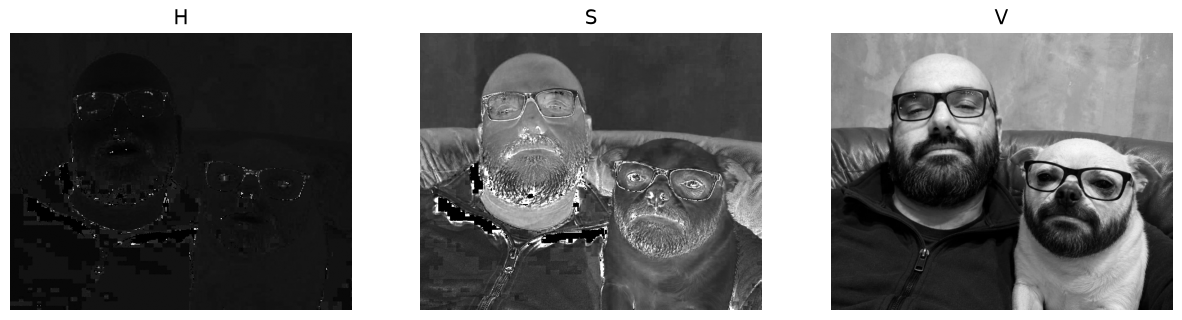

In [139]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, canal, nome in zip(axes, [h, s, v], ['H', 'S', 'V']):
    ax.imshow(canal, cmap='gray')
    ax.set_title(nome)
    ax.axis('off')
plt.show()

### Segmentação por matiz

`cv2.inRange` produz uma máscara binária a partir de limites inferior e superior em HSV. Para o vermelho, são necessárias duas faixas de matiz, combinadas com `cv2.bitwise_or`.

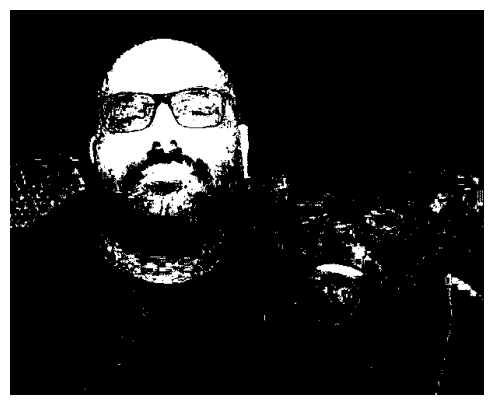

In [140]:
m1 = cv2.inRange(hsv, (0, 40, 40), (10, 255, 255))
m2 = cv2.inRange(hsv, (160, 40, 40), (179, 255, 255))
mask = cv2.bitwise_or(m1, m2)

plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

Pós-processamento: o fechamento morfológico preenche descontinuidades internas da máscara e a seleção do maior contorno descarta regiões espúrias. O tratamento formal das operações morfológicas é objeto de disciplina posterior.

In [ ]:
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))

cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_final = np.zeros_like(mask)
cv2.drawContours(mask_final, [max(cnts, key=cv2.contourArea)], -1, 255, -1)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(495, 610), dtype=uint8)

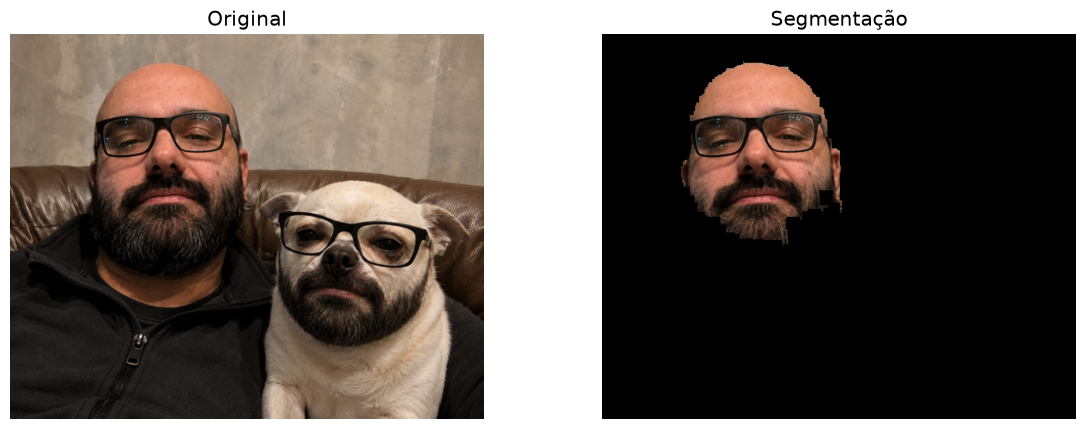

In [142]:
res = cv2.bitwise_and(img, img, mask=mask_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[1].imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
axes[1].set_title('Segmentação')
for ax in axes:
    ax.axis('off')
plt.show()

## Chroma key

### Leitura de video 

Read: True | frame dimensions: (480, 854, 3)


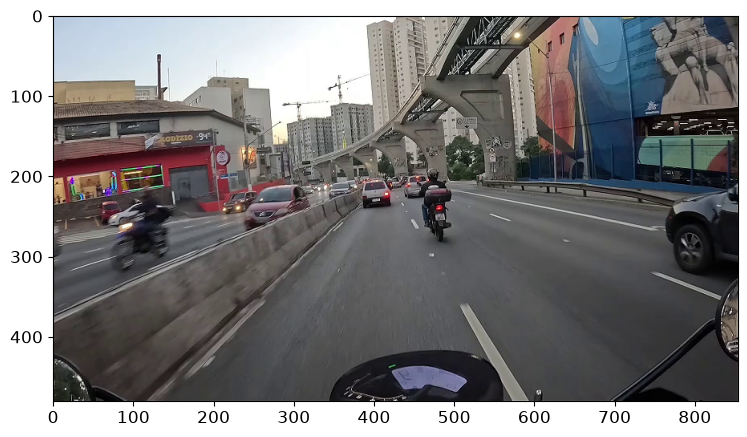

In [56]:
cap = cv2.VideoCapture("../videos/moto_480P_5sec_low.mp4")

ok, frame = cap.read()
print(f"Read: {ok} | frame dimensions: {frame.shape}")

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
# plt.axis('off')
plt.show()

In [12]:
fps = cap.get(cv2.CAP_PROP_FPS)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"FPS: {round(fps, 1)} | frames: {total}")

FPS: 30.0 | frames: 150


Leitura integral, laço sobre `read()` até o retorno `False`, seguido de `release()`.

In [14]:
cap = cv2.VideoCapture("../videos/moto_480P_5sec_low.mp4")
frames = []
while True:
    ok, frame = cap.read()
    if not ok:
        break
    frames.append(frame)

cap.release()
print("Loaded frames:", len(frames))

Loaded frames: 150


### Máscara do fundo

Máscara do cinza via `inRange` em HSV, seguida de fechamento morfológico para preencher descontinuidades.

In [91]:
frame = frames[len(frames) // 2]

# frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

# roi = hsv[300:400, 250:400]
# h = roi[:, :, 0]
# s = roi[:, :, 1]
# v = roi[:, :, 2]

# print(f"H min/max: {h.min()} / {h.max()}")
# print(f"S min/max: {s.min()} / {s.max()}")
# print(f"V min/max: {v.min()} / {v.max()}")

# print("\nPercentis:")
# print(f"S 5%-95%: {np.percentile(s,5):.1f} - {np.percentile(s,95):.1f}")
# print(f"V 5%-95%: {np.percentile(v,5):.1f} - {np.percentile(v,95):.1f}")

# plt.imshow(roi, cmap='gray')
# # plt.axis('off')
# plt.show()

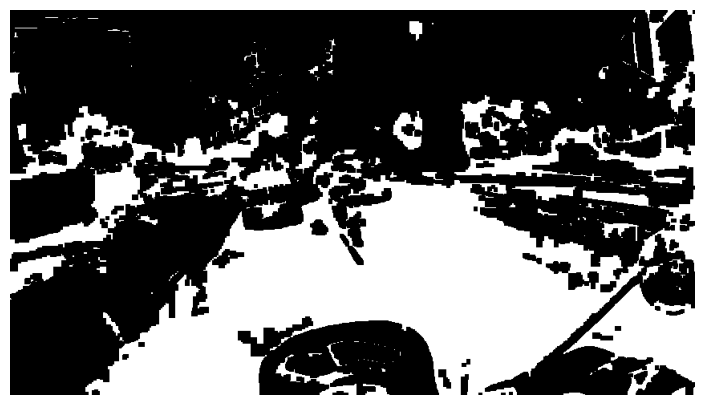

In [92]:

cinza = cv2.inRange(hsv, 
        (30, 10, 40),
        (168, 77, 98)
    )
cinza = cv2.morphologyEx(cinza, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))


plt.imshow(cinza, cmap='gray')
plt.axis('off')
plt.show()

A inversão da máscara marca tudo o que não é cinza (asfalto), o que inclui o entorno do estúdio visível nas bordas da gravação.

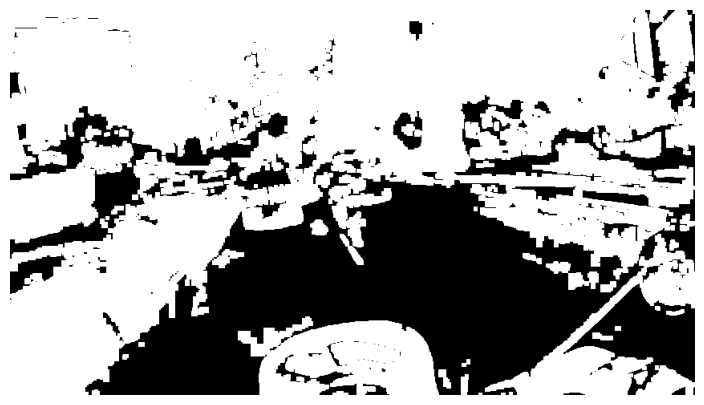

In [99]:
moto = cv2.bitwise_not(cinza)

plt.imshow(moto, cmap='gray')
plt.axis('off')
plt.show()

### Garbage matte

Restrição espacial aplicada antes de qualquer seleção de componente: mantém-se apenas a faixa central do quadro, onde o objeto de interesse se encontra. A ordem é determinante, pois o entorno do estúdio forma um componente conexo que pode exceder a área do objeto.

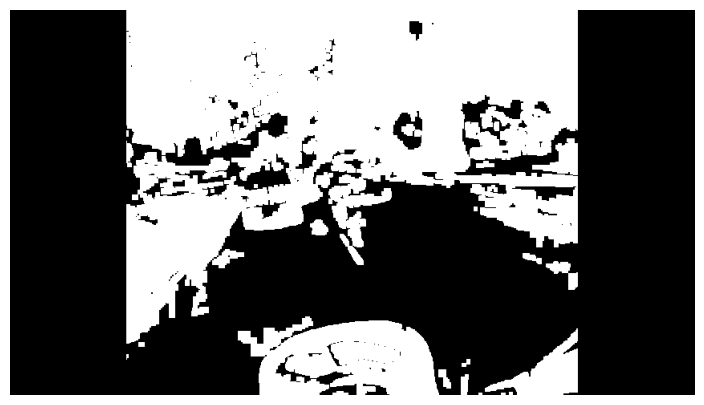

In [100]:
h, w = moto.shape
faixa = np.zeros_like(moto)
faixa[:, int(0.17 * w):int(0.83 * w)] = 255
moto = cv2.bitwise_and(moto, faixa)

plt.imshow(moto, cmap='gray')
plt.axis('off')
plt.show()

Abertura morfológica para remoção de ruído, seleção do maior contorno e suavização da borda da máscara.

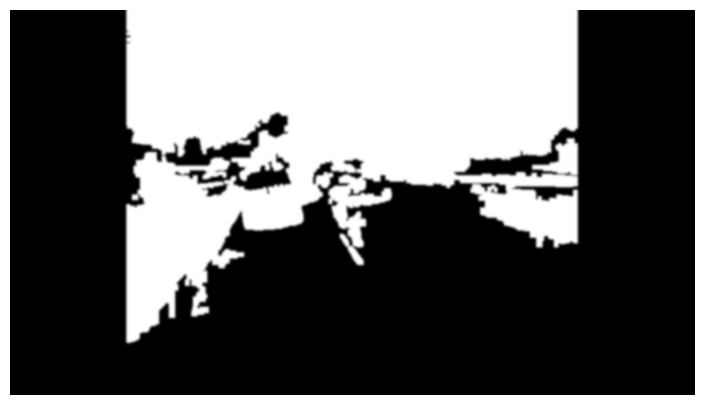

In [104]:
moto = cv2.morphologyEx(moto, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))

cnts, _ = cv2.findContours(moto, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask = np.zeros_like(moto)
if cnts:
    cv2.drawContours(mask, [max(cnts, key=cv2.contourArea)], -1, 255, -1)

mask = cv2.GaussianBlur(mask, (7, 7), 0)

plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

### Composição alfa

A máscara normalizada em [0, 1] pondera a média pixel a pixel entre o quadro e o cenário. A supressão de spill limita o canal G à média dos demais canais, atenuando o reflexo verde na borda do objeto.

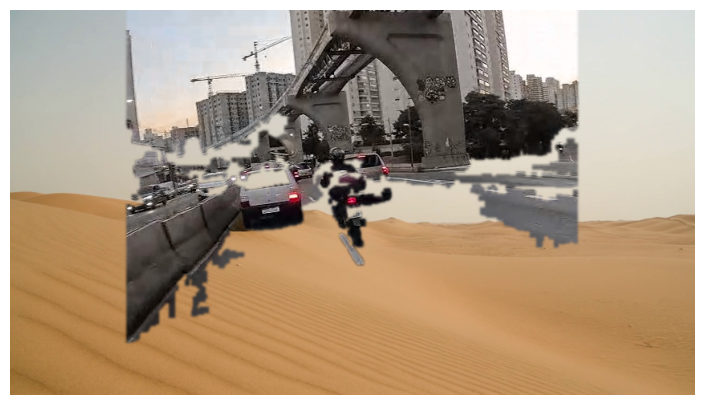

In [105]:
cap = cv2.VideoCapture('../videos/fundo-deserto.mp4')
ok, fundo = cap.read()
cap.release()
fundo = cv2.resize(fundo, (frame.shape[1], frame.shape[0]))

B, G, R = cv2.split(frame.astype(np.int16))
G = np.minimum(G, (B + R) // 2)
frame_ss = cv2.merge([B, G, R]).astype(np.uint8)

alpha = (mask / 255.0)[..., None]
composto = (frame_ss * alpha + fundo * (1 - alpha)).astype(np.uint8)

plt.imshow(cv2.cvtColor(composto, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### Processamento do vídeo completo

A função consolida a sequência de operações na ordem construída acima.

In [109]:
def compor(frame, fundo):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # máscara do fundo cinza
    cinza = cv2.inRange(hsv, (30, 10, 40), (168, 77, 98))
    cinza = cv2.morphologyEx(cinza, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    moto = cv2.bitwise_not(cinza)

    # garbage matte antes da seleção de componente
    h, w = moto.shape
    faixa = np.zeros_like(moto)
    faixa[:, int(0.17 * w):int(0.83 * w)] = 255
    moto = cv2.bitwise_and(moto, faixa)

    # limpeza e maior contorno
    moto = cv2.morphologyEx(moto, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    cnts, _ = cv2.findContours(moto, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(moto)
    if cnts:
        cv2.drawContours(mask, [max(cnts, key=cv2.contourArea)], -1, 255, -1)

    # borda suave e supressão de spill
    mask = cv2.GaussianBlur(mask, (7, 7), 0)
    alpha = (mask / 255.0)[..., None]
    B, G, R = cv2.split(frame.astype(np.int16))
    G = np.minimum(G, (B + R) // 2)
    frame = cv2.merge([B, G, R]).astype(np.uint8)

    # composição
    fundo = cv2.resize(fundo, (frame.shape[1], frame.shape[0]))
    return (frame * alpha + fundo * (1 - alpha)).astype(np.uint8)

In [110]:
cap = cv2.VideoCapture('../videos/fundo-deserto.mp4')
fundo_frames = []
while True:
    ok, f = cap.read()
    if not ok:
        break
    fundo_frames.append(f)
cap.release()

n = min(len(frames), len(fundo_frames))
print('quadros a compor:', n)

quadros a compor: 121


### Escrita do vídeo

`cv2.VideoWriter` requer o arquivo de saída, o codec (`VideoWriter_fourcc`), o FPS e o tamanho do quadro na ordem (largura, altura). `release()` finaliza o arquivo.

In [111]:
h, w = frames[0].shape[:2]
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
saida = cv2.VideoWriter('../videos/resultado2.mp4', fourcc, fps, (w, h))

for i in range(n):
    saida.write(compor(frames[i], fundo_frames[i]))

saida.release()
print('vídeo salvo em resultado2.mp4')

vídeo salvo em resultado2.mp4


Verificação em três instantes do resultado.

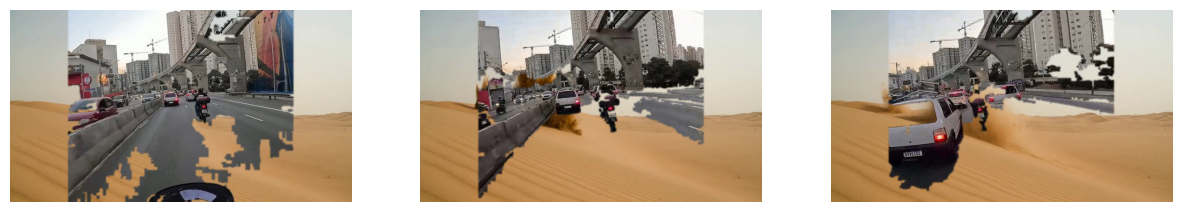

In [112]:
cap = cv2.VideoCapture('../videos/resultado2.mp4')
total_out = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, i in zip(axes, [5, total_out // 2, total_out - 5]):
    cap.set(cv2.CAP_PROP_POS_FRAMES, i)
    ok, f = cap.read()
    ax.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    ax.axis('off')
cap.release()
plt.show()